In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [20]:
data = {
    'Age': [25, 30, 22, 35, 40, 28, 50, 48, 33, 26],
    'Income': [20000, 25000, 18000, 35000, 40000, 27000, 50000, 48000, 32000, 26000]
}

df = pd.DataFrame(data)
df.to_csv("sample_data.csv", index=False)

In [21]:
df = pd.read_csv("sample_data.csv")
print(df.head())

   Age  Income
0   25   20000
1   30   25000
2   22   18000
3   35   35000
4   40   40000


In [4]:
X = df[['Age', 'Income']]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [7]:
labels = kmeans.labels_
print(labels)

[1 1 1 0 2 1 2 2 0 1]


In [8]:
centroids = kmeans.cluster_centers_
print(centroids)

[[ 0.03292729  0.13330915]
 [-0.82318236 -0.84746533]
 [ 1.35001907  1.32356944]]


In [9]:
df['Cluster'] = labels
print(df)

   Age  Income  Cluster
0   25   20000        1
1   30   25000        1
2   22   18000        1
3   35   35000        0
4   40   40000        2
5   28   27000        1
6   50   50000        2
7   48   48000        2
8   33   32000        0
9   26   26000        1


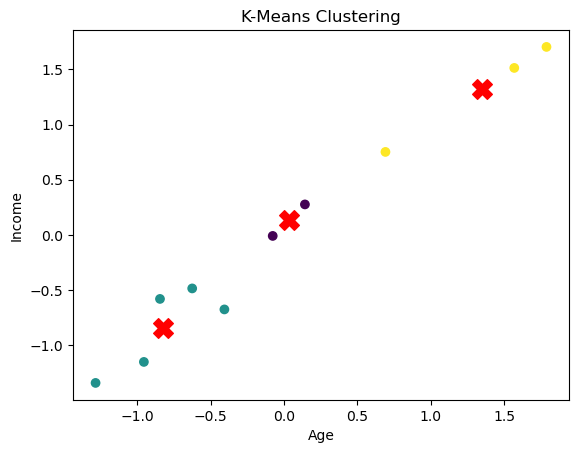

In [10]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200)

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("K-Means Clustering")
plt.show()

In [22]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "cluster_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "saquib7hussain/k-mean-cluster-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

C:\Users\Admin\AppData\Local\Temp\ipykernel_23312\2281405449.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Download already complete (19419 bytes).
First 5 records:    Feature 1  Feature 2
0   2.698582  -0.672960
1  -0.128113   4.355952
2   2.509049   5.773146
3  -1.518276   3.444886
4  -0.072283   2.883769


In [23]:
X = df.select_dtypes(include=['int64', 'float64'])

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [25]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3, random_state=42)

In [26]:
labels = kmeans.labels_
print(labels)

[0 0 2 0 0 1 0 1 0 0 2 0 0 2 0 1 0 1 0 0 0 1 0 0 0 2 0 0 2 0 0 2 0 2 0 0 0
 1 1 1 2 1 0 0 0 0 1 0 0 2 2 1 0 0 1 0 1 1 2 0 0 1 0 0 2 2 0 2 0 0 0 0 0 1
 0 0 0 0 0 0 0 2 2 0 1 0 1 0 0 0 0 2 2 0 1 0 0 0 2 2 0 2 2 0 2 0 1 0 0 0 0
 0 0 1 1 2 2 2 0 1 1 2 0 2 0 0 1 0 2 2 2 0 2 1 2 1 1 1 2 0 0 2 0 0 0 1 1 2
 0 0 2 2 2 0 0 2 0 0 2 0 2 1 0 0 0 0 0 0 1 0 0 2 1 1 0 2 0 2 0 2 0 2 2 1 0
 1 0 0 2 1 2 0 1 0 0 0 0 1 2 2 0 2 2 2 2 0 1 0 0 0 1 2 0 2 1 2 1 0 0 0 0 0
 1 1 1 2 0 1 1 0 0 0 2 2 2 0 2 0 1 2 0 0 2 1 0 0 2 2 0 1 1 0 0 0 0 2 0 0 0
 2 1 0 2 0 0 0 1 0 0 0 0 2 0 0 2 0 2 0 2 2 0 0 0 0 2 0 2 0 2 1 0 0 2 0 0 1
 2 0 1 2 1 0 0 0 2 0 1 0 0 2 1 2 0 1 0 0 2 1 1 1 2 2 0 0 0 2 1 1 0 0 2 0 0
 0 2 0 0 2 0 1 0 2 0 1 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 1 0 0 1 2 2 0 0 0 2 2
 0 0 1 0 0 0 1 0 2 0 1 1 2 1 1 2 2 1 0 2 2 2 0 1 1 1 1 0 2 0 2 0 1 0 0 0 0
 2 0 2 1 0 1 2 0 0 1 2 0 0 1 0 2 0 0 0 0 2 0 2 0 1 2 0 2 0 0 2 0 2 0 1 2 2
 2 0 0 0 2 2 2 0 1 0 0 0 1 0 2 0 1 2 2 1 0 0 2 0 0 0 1 0 2 0 2 0 2 1 0 1 0
 1 0 1 0 2 0 2 2 2 0 1 0 

In [27]:
centroids = kmeans.cluster_centers_
print(centroids)

[[-0.35668062 -0.11325927]
 [ 1.8303297  -1.41319509]
 [-0.65564893  1.26913494]]


In [28]:
df['Cluster'] = labels
print(df)

     Feature 1  Feature 2  Cluster
0     2.698582  -0.672960        0
1    -0.128113   4.355952        0
2     2.509049   5.773146        2
3    -1.518276   3.444886        0
4    -0.072283   2.883769        0
..         ...        ...      ...
495  10.303693  -4.378493        1
496  -0.730000   6.254563        2
497  -3.478708   2.257991        0
498  -2.081214   2.447245        0
499   3.359415   5.248267        0

[500 rows x 3 columns]


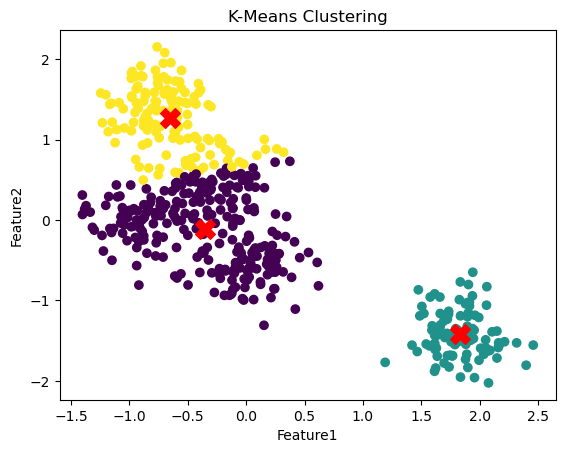

In [30]:
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200)

plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("K-Means Clustering")
plt.show()

C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

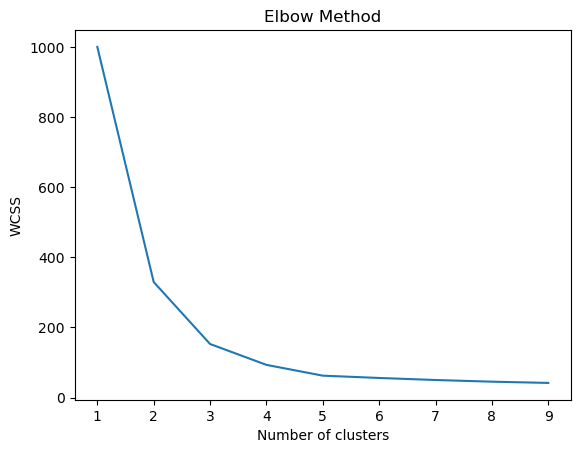

In [31]:
wcss = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

import matplotlib.pyplot as plt
plt.plot(range(1, 10), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [32]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.5363065920716594
